In [1]:
#from matplotlib import unregister_cmap
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.patches as patches

a, b, e, alpha, epsion, mu, c = [
    5.24073718,
    6.10303089,
    0.85355013,
    0.32682177,
    -0.00968044,
    0.84661793,
    -0.27288932,
]

beta = alpha

gamma1, gamma2 = [
    11.08763712,
    4.40474882,
]

c11, c12, c21, c22 = [
    1.90420893,
    1.82159486,
    2.79936732,
    1.36557887,
]

A = np.exp(a)
B = np.exp(b)
E = np.exp(e)

def optimal_N(C,s):
    a = (beta)/(alpha+beta)
    #scale = (s)**((epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    N_opt = scale*G*(C/6)**a
    return N_opt

def N_to_C(N,s):
    a = (beta)/(alpha+beta)
    #scale = (s)**((epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    C = ((N/G/scale) ** (1/a)) * 6 
    return C

def optimal_D(C,s):
    b = (alpha)/(alpha+beta)
    #scale = (s)**(-(epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    D_opt = scale*(1/G)*(C/6)**b
    return D_opt

def D_to_C(D,s):
    b = (alpha)/(alpha+beta)
    #scale = (s)**(-(epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    C = ((G*D/scale) ** (1/b)) * 6 
    return C

def scaling_law(N, U, D, S):
    
    a, b, e, alpha, epsion, mu, c = [
    5.24073718,
    6.10303089,
    0.85355013,
    0.32682177,
    -0.00968044,
    0.84661793,
    -0.27288932]

    beta = alpha

    gamma1, gamma2 = [
        11.08763712,
        4.40474882,
    ]

    c11, c12, c21, c22 = [
        1.90420893,
        1.82159486,
        2.79936732,
        1.36557887,
    ]    
    
    A = np.exp(a)
    B = np.exp(b)
    E = np.exp(e)
    
  
    UN = np.minimum(N,optimal_N(D_to_C(U, S), S))
    
    rn = np.maximum((N / UN ) - 1, 0)
    rd = np.maximum((D / U) - 1, 0)
    
    # n_star = gamma1*(1+np.exp(-N/(U**deta1*S**c21))*(1+S*c11-c11*S**2))
    # d_star = gamma2*(1+np.exp(-N/(U**deta2*S**c22))*(1+S*c12-c12*S**2))
    
    n_star = gamma1*(1+(1-S)*c11-c21*(1-S)**2)
    d_star = gamma2*(1+(1-S)*c12-c22*(1-S)**2)
    
    # Compute N' and D' according to the formula
    N_eff = (UN + UN * (n_star) * (1 - np.exp(-rn/(n_star))))**alpha #*np.exp(-rn/(n_star))
    D_eff = ((U + U * (d_star) * (1 - np.exp(-rd/(d_star)))))**beta
    

    L = E + A*(S**epsion+c*(1-S)**mu)/(N_eff) + B/(D_eff)
    return L

/tmp/ipykernel_2124/2448115733.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.3, 1, 1])


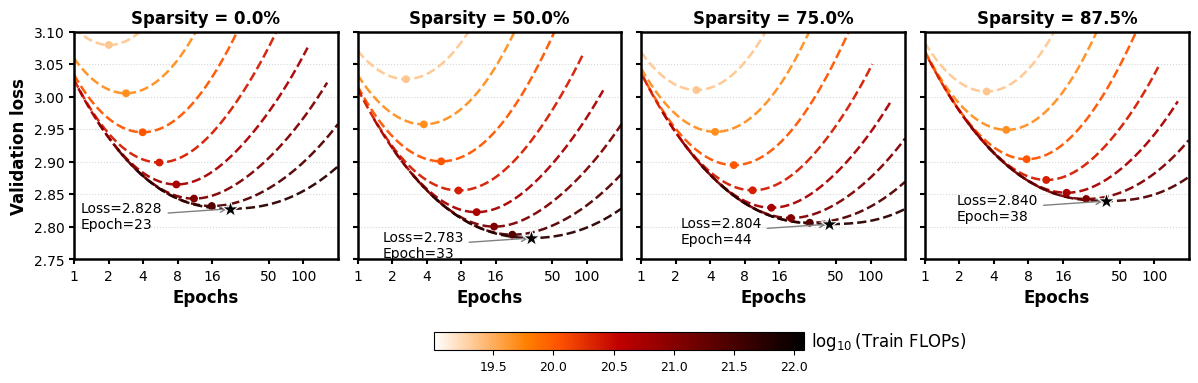

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Global constants
# ============================================================
UT = 1.3e9   # token unit


# ============================================================
# 1. Global shared FLOPs grid (CRITICAL)
# ============================================================
MIN_PARAMS, MAX_PARAMS = 1.3e9, 1e10
MIN_TOKS,   MAX_TOKS   = 1.3e9, 2e11

f_min = MIN_PARAMS * MIN_TOKS * 6
f_max = MAX_PARAMS * MAX_TOKS * 6

F_list = np.logspace(np.log10(f_min), np.log10(f_max), 10)


# ============================================================
# 2. Compute isoFLOPs slices for one sparsity
# ============================================================
def compute_slices(S, F_list):

    P = optimal_N(D_to_C(UT, S), S)
    start_t, end_t = np.log10(1), np.log10(50)

    slices = []

    for F in F_list:
        C = F / 6.0
        t = optimal_D(C, S)
        s = optimal_N(C, S)

        if not (start_t <= np.log10(t / UT) <= end_t):
            continue

        best_l = scaling_law(s, min(UT, t), t, S)
        best_D, best_N = t, s

        cand_toks, cand_loss = [], []

        def record(D, N):
            L = scaling_law(N, min(UT, D), D, S)
            cand_toks.append(D / UT)
            cand_loss.append(L)
            return L

        record(t, s)

        for scale in np.linspace(1.0001, 10.0, 500):
            for D, N in [(t * scale, s / scale),
                         (t / scale, s * scale)]:
                L = record(D, N)
                if L < best_l:
                    best_l, best_D, best_N = L, D, N

        slices.append({
            "F": F,  # <<< SAME FLOPs ACROSS ALL S
            "toks": np.array(cand_toks),
            "loss": np.array(cand_loss),
            "best": {
                "toks": best_D / UT,
                "loss": best_l
            }
        })

    return slices


# ============================================================
# 3. Compute all sparsities
# ============================================================
S_list = [1.0, 0.5, 0.25, 0.125]
all_slices = [compute_slices(S, F_list) for S in S_list]

# For shared colorbar
all_F = np.array(F_list)

# ============================================================
# 4. Plot 1 × 4
# ============================================================
fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

cmap = plt.get_cmap("gist_heat_r")
norm = plt.Normalize(np.log10(all_F.min()), np.log10(all_F.max()))

for ax, S, slices in zip(axes, S_list, all_slices):

    F_vals  = np.array([sl["F"] for sl in slices])
    x_best  = np.array([sl["best"]["toks"] for sl in slices])
    y_best  = np.array([sl["best"]["loss"] for sl in slices])

    # ---- IsoFLOPs curves ----
    for sl in slices:
        order = np.argsort(sl["toks"])
        xs = sl["toks"][order]
        ys = sl["loss"][order]
        col = cmap(norm(np.log10(sl["F"])))
        ax.plot(np.log10(xs), ys, "--", lw=1.8, color=col, alpha=0.95)

    # ---- Best points ----
    sc = ax.scatter(
        np.log10(x_best),
        y_best,
        c=np.log10(F_vals),
        cmap=cmap,
        norm=norm,
        s=32,
        edgecolor="none",
        zorder=3
    )

    idx = np.argmin(y_best)
    x_star, y_star = x_best[idx], y_best[idx]

    ax.scatter(
        np.log10(x_star),
        y_star,
        s=160,
        marker="*",
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=6
    )

    ax.annotate(
        f"Loss={y_star:.3f}\nEpoch={x_star:.0f}",
        xy=(np.log10(x_star), y_star),
        xytext=(np.log10(x_star)-1.3, y_star-0.03),
        fontsize=10,
        arrowprops=dict(arrowstyle="->", lw=1.0, color="gray")
    )

    ax.set_title(f"Sparsity = {(1-S)*100:.1f}%", fontsize=12, fontweight='bold')
    ax.grid(True, axis="y", ls=":", alpha=0.5)


# ============================================================
# 5. Shared axes
# ============================================================
axes[0].set_ylabel("Validation loss", fontsize=12, fontweight='bold')
for ax in axes:
    ax.set_xlabel("Epochs", fontsize=12, fontweight='bold')

axes[0].set_xlim(np.log10(1), np.log10(200))
axes[0].set_ylim(2.75, 3.1)

x_ticks = [1, 2, 4, 8, 16, 50, 100]
axes[0].set_xticks(np.log10(x_ticks), [str(x) for x in x_ticks])

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(width=1.5)
    
# ============================================================
# 6. Shared colorbar (bottom, title on right)
# ============================================================
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.35
)
cbar.ax.tick_params(labelsize=9)

# Put label on the RIGHT
cbar.set_label("")
cbar.ax.text(
    1.02, 0.5,
    r"$\log_{10}(\mathrm{Train\ FLOPs})$",
    transform=cbar.ax.transAxes,
    va="center",
    ha="left",
    fontsize=12
)

plt.tight_layout(rect=[0, 0.3, 1, 1])
plt.savefig("isoFLOPs_1x4_sparsity_sharedF.pdf", dpi=300)
plt.savefig("isoFLOPs_1x4_sparsity_sharedF.png", dpi=300)
plt.show()

In [3]:
#from matplotlib import unregister_cmap
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.patches as patches

a, b, e, alpha, epsion, mu, c = [
    5.24073718,
    6.10303089,
    0.85355013,
    0.32682177,
    -0.00968044,
    0.84661793,
    -0.27288932]

beta = alpha

gamma1, gamma2 = [
    11.08763712,
    4.40474882,
]

c11, c12, c21, c22 = [
    1.90420893,
    1.82159486,
    2.79936732,
    1.36557887,
]
A = np.exp(a)
B = np.exp(b)
E = np.exp(e)

def optimal_N(C,s):
    a = (beta)/(alpha+beta)
    #scale = (s)**((epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    N_opt = scale*G*(C*s/6)**a
    return N_opt

def N_to_C(N,s):
    a = (beta)/(alpha+beta)
    #scale = (s)**((epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    C = ((N/G/scale) ** (1/a)) * 6 / s
    return C

def optimal_D(C,s):
    b = (alpha)/(alpha+beta)
    #scale = (s)**(-(epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    D_opt = scale*(1/G)*(C*s/6)**b
    return D_opt

def D_to_C(D,s):
    b = (alpha)/(alpha+beta)
    #scale = (s)**(-(epsion)/(alpha + beta))
    scale = 1
    A_t = (s**epsion + c*(1-s)**mu) *A 
    G = ((alpha*A_t)/(beta*B))**(1/(alpha+beta))
    C = ((G*D/scale) ** (1/b)) * 6 / s
    return C

def scaling_law(N, U, D, S):
    
    a, b, e, alpha, epsion, mu, c = [
    5.24073718,
    6.10303089,
    0.85355013,
    0.32682177,
    -0.00968044,
    0.84661793,
    -0.27288932]

    beta = alpha

    gamma1, gamma2 = [
        11.08763712,
        4.40474882,
    ]

    c11, c12, c21, c22 = [
        1.90420893,
        1.82159486,
        2.79936732,
        1.36557887,
    ]    
    
    A = np.exp(a)
    B = np.exp(b)
    E = np.exp(e)
    
  
    UN = np.minimum(N,optimal_N(D_to_C(U, S), S))
    
    rn = np.maximum((N / UN ) - 1, 0)
    rd = np.maximum((D / U) - 1, 0)
    
    # n_star = gamma1*(1+np.exp(-N/(U**deta1*S**c21))*(1+S*c11-c11*S**2))
    # d_star = gamma2*(1+np.exp(-N/(U**deta2*S**c22))*(1+S*c12-c12*S**2))
    
    n_star = gamma1*(1+(1-S)*c11-c21*(1-S)**2)
    d_star = gamma2*(1+(1-S)*c12-c22*(1-S)**2)
    
    # Compute N' and D' according to the formula
    N_eff = (UN + UN * (n_star) * (1 - np.exp(-rn/(n_star))))**alpha #*np.exp(-rn/(n_star))
    D_eff = ((U + U * (d_star) * (1 - np.exp(-rd/(d_star)))))**beta
    

    L = E + A*(S**epsion+c*(1-S)**mu)/(N_eff) + B/(D_eff)
    return L

/tmp/ipykernel_2124/3181606052.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.3, 1, 1])


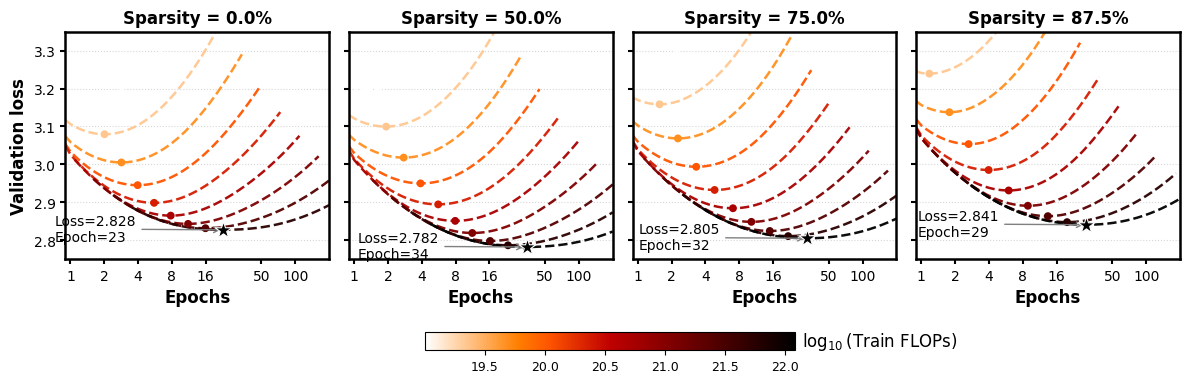

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Global constants
# ============================================================
UT = 1.3e9   # token unit

# ============================================================
# --------- 你已有的函数（假定已定义）---------
# optimal_N, optimal_D, D_to_C, scaling_law
# ============================================================


# ============================================================
# 1. Global shared FLOPs grid (CRITICAL)
# ============================================================
MIN_PARAMS, MAX_PARAMS = 1.3e9, 1e10
MIN_TOKS,   MAX_TOKS   = 1.3e9, 2e11

f_min = MIN_PARAMS * MIN_TOKS * 6
f_max = MAX_PARAMS * MAX_TOKS * 6

F_list = np.logspace(np.log10(f_min), np.log10(f_max), 10)


# ============================================================
# 2. Compute isoFLOPs slices for one sparsity
# ============================================================
def compute_slices(S, F_list):

    P = optimal_N(D_to_C(UT, S), S)
    start_t, end_t = np.log10(0.1), np.log10(50)

    slices = []

    for F in F_list:
        C = F / 6.0
        t = optimal_D(C, S)
        s = optimal_N(C, S)

        if not (start_t <= np.log10(t / UT) <= end_t):
            continue

        best_l = scaling_law(s, min(UT, t), t, S)
        best_D, best_N = t, s

        cand_toks, cand_loss = [], []

        def record(D, N):
            L = scaling_law(N, min(UT, D), D, S)
            cand_toks.append(D / UT)
            cand_loss.append(L)
            return L

        record(t, s)

        for scale in np.linspace(1.0001, 10.0, 500):
            for D, N in [(t * scale, s / scale),
                         (t / scale, s * scale)]:
                L = record(D, N)
                if L < best_l:
                    best_l, best_D, best_N = L, D, N

        slices.append({
            "F": F,  # <<< SAME FLOPs ACROSS ALL S
            "toks": np.array(cand_toks),
            "loss": np.array(cand_loss),
            "best": {
                "toks": best_D / UT,
                "loss": best_l
            }
        })

    return slices


# ============================================================
# 3. Compute all sparsities
# ============================================================
S_list = [1.0, 0.5, 0.25, 0.125]
all_slices = [compute_slices(S, F_list) for S in S_list]

# For shared colorbar
all_F = np.array(F_list)

# ============================================================
# 4. Plot 1 × 4
# ============================================================
fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

cmap = plt.get_cmap("gist_heat_r")
norm = plt.Normalize(np.log10(all_F.min()), np.log10(all_F.max()))

for ax, S, slices in zip(axes, S_list, all_slices):

    F_vals  = np.array([sl["F"] for sl in slices])
    x_best  = np.array([sl["best"]["toks"] for sl in slices])
    y_best  = np.array([sl["best"]["loss"] for sl in slices])

    # ---- IsoFLOPs curves ----
    for sl in slices:
        order = np.argsort(sl["toks"])
        xs = sl["toks"][order]
        ys = sl["loss"][order]
        col = cmap(norm(np.log10(sl["F"])))
        ax.plot(np.log10(xs), ys, "--", lw=1.8, color=col, alpha=0.95)

    # ---- Best points ----
    sc = ax.scatter(
        np.log10(x_best),
        y_best,
        c=np.log10(F_vals),
        cmap=cmap,
        norm=norm,
        s=32,
        edgecolor="none",
        zorder=3
    )

    idx = np.argmin(y_best)
    x_star, y_star = x_best[idx], y_best[idx]

    ax.scatter(
        np.log10(x_star),
        y_star,
        s=160,
        marker="*",
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=6
    )

    ax.annotate(
        f"Loss={y_star:.3f}\nEpoch={x_star:.0f}",
        xy=(np.log10(x_star), y_star),
        xytext=(np.log10(x_star)-1.5, y_star-0.03),
        fontsize=10,
        arrowprops=dict(arrowstyle="->", lw=1.0, color="gray")
    )

    ax.set_title(f"Sparsity = {(1-S)*100:.1f}%", fontsize=12, fontweight='bold')
    ax.grid(True, axis="y", ls=":", alpha=0.5)
    
    



# ============================================================
# 5. Shared axes
# ============================================================
axes[0].set_ylabel("Validation loss", fontsize=12, fontweight='bold')
for ax in axes:
    ax.set_xlabel("Epochs", fontsize=12, fontweight='bold')

axes[0].set_xlim(np.log10(0.9), np.log10(200))
axes[0].set_ylim(2.75, 3.35)

x_ticks = [1, 2, 4, 8, 16, 50, 100]
axes[0].set_xticks(np.log10(x_ticks), [str(x) for x in x_ticks])

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(width=1.5)


# ============================================================
# 6. Shared colorbar (bottom, title on right)
# ============================================================
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.35
)
cbar.ax.tick_params(labelsize=9)

# Put label on the RIGHT
cbar.set_label("")
cbar.ax.text(
    1.02, 0.5,
    r"$\log_{10}(\mathrm{Train\ FLOPs})$",
    transform=cbar.ax.transAxes,
    va="center",
    ha="left",
    fontsize=12
)

plt.tight_layout(rect=[0, 0.3, 1, 1])
plt.savefig("isoFLOPs_1x4_sparsity_sharedF.pdf", dpi=300)
plt.savefig("isoFLOPs_1x4_sparsity_sharedF.png", dpi=300)
plt.show()
